# Laboratorio 2

## Integrantes

| Nombre                            | Carnet | Usuario Git |
| --------------------------------- | ------ | ----------- |
| Edwin Jose Gabriel De Leon Garcia | 22809  | EJGDLG      |
| Gustavo Adolfo Cruz Bardales      | 22779  | G2309       |
| Josué Emanuel Say Garcia          | 22801  | JosueSay    |
| Mathew Alexander Cordero Aquino   | 22982  | donmatthiuz |


## Repositorio

[Link al Repositorio](https://github.com/donmatthiuz/RL/tree/lab2)

## Caso

Una empresa de gestión de infraestructura hospitalaria opera un sistema de ascensores en un edificio de cinco pisos. En horas críticas, el tiempo de espera de camillas y personal médico tiene consecuencias directas sobre la atención al paciente. La gerencia quiere optimizar la política de despacho de ascensores usando Programación Dinámica antes de comprometer presupuesto en un sistema de aprendizaje completo.

Su grupo ha sido contratado para modelar el problema como un MDP, implementar Policy Iteration y Value Iteration desde cero, comparar su comportamiento, y producir un dictamen técnico con recomendaciones concretas para la gerencia.

## Task 1

Dado el contexto del sistema de ascensores, diseñen formalmente el MDP que representa el problema. El diseño debe especificar con precisión y justificación:

### Inciso 1

El espacio de estados $S$: ¿qué variables definen completamente la situación del sistema en un instante dado? Justifiquen cada variable incluida y cada variable omitida. Para cada variable omitida, argumenten qué supuesto están haciendo y qué consecuencia tiene ese supuesto sobre la validez del modelo.

**Respuesta:**

El estado debe resumir todo el pasado relevante para decidir:

$$
s = (f, d, \mathbf{u}, \mathbf{v}, e)
$$

**Variables:**

| Variable | Dominio | Justificación |
|---|---|---|
| $f$ | $\{1,\dots,5\}$ | Piso actual. Sin ella no hay noción de transición ni de costo de desplazamiento. |
| $d$ | $\{\text{sube},\ \text{baja},\ \text{detenido}\}$ | Sentido de marcha. Invertir la marcha cuesta tiempo, continuarla no. |
| $\mathbf{u}$ | $\{0,1\}^{5}$ | Llamadas externas pendientes por piso: la demanda que justifica mover la cabina. |
| $\mathbf{v}$ | $\{0,1\}^{5}$ | Destinos internos solicitados por pasajeros a bordo. |
| $e$ | $\{0,1\}^{5}$ | Llamada de emergencia por piso. Permite priorizar sin mezclar con la demanda ordinaria. |

Cardinalidad: $|\mathcal{S}| = 5 \cdot 3 \cdot 2^{5} \cdot 2^{5} \cdot 2^{5} = 491\,520$ estados. Es finito, que es lo que permite tratarlo de forma tabular.

Separar $\mathbf{u}$ de $\mathbf{v}$ es crítico: colapsarlas haría indistinguible un piso donde alguien espera de uno donde un pasajero quiere bajar. Igual $e$: sin esa marca, una emergencia y una llamada ordinaria en el mismo piso colapsan al mismo estado.

**Variables omitidas:**

- **Historial de trayectoria.** El piso actual más el sentido de marcha ya resumen el pasado relevante, que es justamente lo que exige la propiedad de Markov. Conservarla haría explotar $|\mathcal{S}|$ sin ganancia.
- **Tiempo de espera acumulado por llamada.** Se internaliza como costo negativo por paso en vez de guardarse en el estado. Consecuencia: el modelo no distingue una llamada recién registrada de una antigua. Incluirlo exigiría un contador discretizado por piso y $|\mathcal{S}|$ crecería multiplicativamente.
- **Número de personas esperando y ocupación de la cabina.** Se asume que toda llamada pesa igual y que la capacidad no se satura. El agente no puede saltarse un piso por cabina llena.
- **Hora del día.** Se asume que las probabilidades de transición no cambian con el tiempo. Es el supuesto más frágil, porque la demanda hospitalaria tiene picos por cambio de turno. Mitigación: resolver un MDP distinto por franja horaria.

Regla aplicada: se incluye una variable si su omisión hace que dos situaciones con valores $V^{\pi}$ distintos colapsen en el mismo estado.

### Inciso 2

El espacio de acciones $A$: definan las acciones disponibles para el sistema de control. Argumenten si el espacio debe ser discreto o continuo para este dominio, y si existen acciones que deben restringirse en ciertos estados o cómo se modela esa restricción.

**Respuesta:**

Espacio discreto y finito:

$$
\mathcal{A} = \{\text{Subir},\ \text{Bajar},\ \text{Detenerse y abrir},\ \text{Esperar}\}
$$

- **Subir / Bajar**: desplazan la cabina un piso.
- **Detenerse y abrir**: atiende el piso actual, limpiando la llamada externa y el destino interno correspondientes.
- **Esperar**: mantiene posición sin abrir. Racional cuando no hay demanda.

Un ascensor solo se detiene en cinco lugares. Con $|\mathcal{A}| = 4$ y $|\mathcal{S}|$ finito, el $\arg\max_a$ de la ecuación de optimalidad se calcula recorriendo cuatro opciones por estado.

**Restricción de acciones por estado**

Se define $\mathcal{A}(s) \subseteq \mathcal{A}$.

1. **Restricción estructural**: fijar $\pi(a \mid s) = 0$ para $a \notin \mathcal{A}(s)$. El agente nunca considera lo imposible.
2. **Restricción por recompensa**: mantener $\mathcal{A}$ completo; la acción inválida devuelve al mismo estado con recompensa muy negativa. El agente aprende la restricción.

### Inciso 3

La función de recompensa $r(s,a,s')$: diseñen una función que capture el objetivo operacional real. Consideren al menos los siguientes objetivos potencialmente conflictivos: minimizar tiempo de espera promedio, priorizar pisos de emergencia, y minimizar consumo energético. Argumenten cómo ponderar esos objetivos y qué consecuencias tendría una ponderación incorrecta sobre el comportamiento del agente.

**Respuesta:**

El agente optimiza lo que se le pidió, no lo que se pensó pedirle. Los tres objetivos en tensión son tiempo de espera, prioridad de emergencia y consumo energético:

$$
r(s,a,s') = w_{t} \cdot r_{\text{espera}} + w_{e} \cdot r_{\text{emergencia}} + w_{c} \cdot r_{\text{energia}}
$$

**Componentes y valores propuestos**

| Componente | Evento | Valor base | Peso |
|---|---|---|---|
| $r_{\text{espera}}$ | Llamada ordinaria pendiente en $s'$, por paso | $-1$ | $w_{t} = 1$ |
| $r_{\text{emergencia}}$ | Llamada de emergencia pendiente en $s'$, por paso | $-10$ | $w_{e} = 1$ |
| $r_{\text{emergencia}}$ | Atender un piso con $e_i = 1$ | $+50$ | $w_{e} = 1$ |
| $r_{\text{espera}}$ | Atender una llamada ordinaria | $+10$ | $w_{t} = 1$ |
| $r_{\text{energia}}$ | Mover la cabina un piso | $-0.5$ | $w_{c} = 1$ |
| $r_{\text{energia}}$ | Detenerse y abrir sin demanda | $-2$ | $w_{c} = 1$ |

La penalización por llamada pendiente se aplica por paso y sobre todas las llamadas activa haciendo que el costo crezca con el tiempo de espera sin necesidad de almacenar contadores en el estado.

Principio ordenador: penalizar el estado indeseable (gente esperando) es más robusto que premiar el evento deseable (atender), porque lo primero no se puede satisfacer sin resolver realmente el problema.

### Inciso 4

La función de transición $p(s' \mid s,a)$: argumenten si el entorno es determinista o estocástico. Si es estocástico, identifiquen las fuentes de aleatoriedad y escriban al menos cuatro transiciones concretas con sus probabilidades justificadas.

**Respuesta:**

Estocástico porque el agente controla sus acciones, no las consecuencias puede decidir Subir, pero no decide quién pulsa un botón mientras tanto.

El movimiento en sí es determinista: si la cabina está en el piso 2 y sube, llega al piso 3 con probabilidad $1$. Lo aleatorio es qué llamadas aparecen durante ese paso. Se modela cada piso como un ensayo de Bernoulli independiente:

- **Llamada ordinaria** en el piso $i$ con probabilidad $\lambda_i$.
- **Emergencia** en el piso $i$ con probabilidad $\mu$, mucho menor.

Tasas propuestas: $\lambda = 0.20$ para los pisos $2$ a $5$, $\lambda_1 = 0.40$ para el vestíbulo por su mayor tránsito, y $\mu = 0.05$ para emergencias en cualquier piso.

Partiendo siempre del mismo estado

$$
s = (f{=}2,\ d{=}\text{sube},\ \mathbf{u}{=}[0,0,0,1,0],\ \mathbf{v}{=}\mathbf{0},\ e{=}\mathbf{0})
$$

con $a = \text{Subir}$, la cabina termina en el piso $3$ con certeza. Lo que cambia entre los estados siguientes posibles es qué llamadas se registraron:

| Estado siguiente $s'$ | Evento | $p(s' \mid s, a)$ | Valor |
|---|---|---|---|
| $(3, \text{sube}, [0,0,0,1,0], \mathbf{0}, \mathbf{0})$ | Ningún piso genera llamada | $(1-\lambda_1)(1-\lambda)^{4}$ | $0.246$ |
| $(3, \text{sube}, [1,0,0,1,0], \mathbf{0}, \mathbf{0})$ | Llamada nueva en el vestíbulo | $\lambda_1 (1-\lambda)^{4}$ | $0.164$ |
| $(3, \text{sube}, [0,0,0,1,0], \mathbf{0}, [0,0,0,0,1])$ | Emergencia en el piso $5$ | $\mu (1-\lambda_1)(1-\lambda)^{4}$ | $0.012$ |

### Inciso 5

El factor de descuento $\gamma$: propongan un valor y justifíquenlo en términos del dominio, no solo matemáticamente. ¿Cómo cambia la política óptima si $\gamma$ es cercano a $0$ versus cercano a $1$ en este contexto específico?

**Respuesta:**

$\gamma = 0.95$ un paso son unos pocos segundos y las consecuencias de una decisión se despliegan a lo largo de decenas de pasos. Con $\gamma = 0.95$ el horizonte efectivo es $1/(1-\gamma) = 20$ pasos, aproximadamente un recorrido completo del edificio.

El problema es **continuo**, no episódico, porque un ascensor no termina. Un $\gamma < 1$ mantiene finito el retorno acumulado y garantiza que el operador de Bellman sea una contracción, sin lo cual la iteración no converge.

- **$\gamma$ cercano a $0$ (miope).** Solo cuenta la recompensa inmediata es decir que se atiende siempre el piso más cercano con demanda. La cabina oscila entre pisos contiguos mientras una emergencia en el extremo opuesto no se atiende, porque el costo de los pasos de desplazamiento pesa más que la recompensa descontada de llegar.
- **$\gamma$ cercano a $1$ (previsor).** Planifica recorridos completos y acepta pasar de largo demanda ordinaria para llegar antes a una emergencia lejana. El costo es doble: la contracción se debilita al acercarse $\gamma$ a $1$, así que la convergencia es más lenta, y la política se vuelve más sensible a errores en la estimación de $p$.

El valor $0.95$ ubica el modelo del lado previsor sin llegar al extremo donde la convergencia se vuelve impracticable.

## Task 2

Respondan las siguientes preguntas con argumentación técnica.

### Inciso 1

Para el MDP que diseñaron, ¿cuántas políticas deterministas posibles existen? Calculen el valor exacto y argumenten por qué la enumeración exhaustiva es inviable incluso para este problema relativamente pequeño.

Respuesta:

Una política determinista asigna una acción a cada estado, de forma independiente entre estados. Entonces son $|\mathcal{A}|$ opciones por estado y el total es:

$$
|\Pi_{\text{det}}| = |\mathcal{A}|^{|\mathcal{S}|} = 4^{491\,520} = 2^{983\,040}
$$

En notación decimal:

$$
4^{491\,520} \approx 3.36 \times 10^{295\,924}
$$

es decir, un número de $295\,925$ dígitos.

Por qué la enumeración exhaustiva no sirve

| Referencia | Orden de magnitud |
|---|---|
| Átomos en el universo observable | $10^{80}$ |
| Políticas del MDP diseñado | $10^{295\,924}$ |

La comparación no es retórica, es el punto: no existe forma de almacenar ni recorrer ese conjunto. Aunque se evaluara una política por nanosegundo desde el Big Bang, se habrían cubierto unas $10^{27}$, una fracción indistinguible de cero.

Y el conteo es solo la mitad del problema. Enumerar exige además evaluar cada política, y cada evaluación cuesta resolver un sistema lineal de $491\,520$ incógnitas o correr cientos de barridos de Bellman. El costo real es el producto de ambas cosas.

Restringir acciones por estado con $\mathcal{A}(s)$ tampoco rescata la idea. Aun dejando solo dos acciones válidas por estado, quedan $2^{491\,520} \approx 10^{147\,962}$ políticas, la mitad de los dígitos y exactamente la misma imposibilidad.

Esto es justamente lo que justifica Programación Dinámica: Policy Iteration y Value Iteration nunca enumeran el espacio de políticas, lo recorren guiadas por la ecuación de Bellman y llegan al óptimo en un número de iteraciones que crece con $\gamma$ y con la precisión pedida, no con el número de políticas.

Para dimensionar el contraste, el MDP simplificado de la Task 3 tiene $10$ estados y $3$ acciones, o sea $3^{10} = 59\,049$ políticas. Ahí sí se podrían enumerar todas. Basta pasar de $10$ a medio millón de estados para que la misma estrategia deje de existir como opción.

### Inciso 2

Dado que $T^\pi$ es una contracción con factor $\gamma$, ¿cuántas iteraciones de Policy Evaluation necesitan teóricamente para reducir el error inicial a menos de $\theta = 0.01$, asumiendo un error inicial de $\lVert V_0 - V^\pi \rVert_\infty \le \dfrac{R_{\max}}{1-\gamma}$? Desarrollen el cálculo usando la cota de convergencia geométrica y el valor de $\gamma$ que propusieron.

Respuesta:

Que $T^{\pi}$ sea una contracción de factor $\gamma$ significa que cada barrido acerca la estimación al punto fijo en al menos esa proporción:

$$
\lVert T^{\pi}V - T^{\pi}U \rVert_{\infty} \le \gamma \lVert V - U \rVert_{\infty}
$$

Como $V^{\pi}$ es el punto fijo ($T^{\pi}V^{\pi} = V^{\pi}$), aplicando la desigualdad $k$ veces:

$$
\lVert V_{k} - V^{\pi} \rVert_{\infty} \le \gamma^{k} \lVert V_{0} - V^{\pi} \rVert_{\infty} \le \gamma^{k}\,\frac{R_{\max}}{1-\gamma}
$$

Datos del diseño

$\gamma = 0.95$ y $R_{\max} = 50$, la recompensa de mayor magnitud de la Task 1 (atender un piso en emergencia). El error inicial acotado queda:

$$
\frac{R_{\max}}{1-\gamma} = \frac{50}{0.05} = 1000
$$

Cálculo

Se pide $\gamma^{k}\,\dfrac{R_{\max}}{1-\gamma} < \theta$:

$$
0.95^{k} \cdot 1000 < 0.01
\quad\Longrightarrow\quad
0.95^{k} < 10^{-5}
$$

Tomando logaritmo y recordando que $\ln \gamma < 0$ (la desigualdad se invierte):

$$
k > \frac{\ln(10^{-5})}{\ln(0.95)} = \frac{-11.5129}{-0.051293} = 224.45
$$

$$
\boxed{k = 225 \text{ iteraciones}}
$$

Verificación: $0.95^{224} \cdot 1000 = 0.01023 > \theta$ y $0.95^{225} \cdot 1000 = 0.00972 < \theta$. La cuenta cierra en el entero justo.

Lecturas del resultado

La fórmula general es

$$
k \ge \frac{\ln\!\big(\theta (1-\gamma) / R_{\max}\big)}{\ln \gamma}
$$

y de ahí salen dos cosas útiles:

| $\gamma$ | Horizonte $1/(1-\gamma)$ | $R_{\max}/(1-\gamma)$ | Iteraciones |
|---|---|---|---|
| $0.50$ | $2$ | $100$ | $14$ |
| $0.75$ | $4$ | $200$ | $35$ |
| $0.95$ | $20$ | $1000$ | $225$ |
| $0.99$ | $100$ | $5000$ | $1306$ |

1. $\gamma$ manda. Pasar de $0.95$ a $0.99$ multiplica por casi seis el trabajo, porque $\gamma$ aparece en la base de la exponencial y además infla la cota inicial. Es el costo concreto de ser previsor que se anticipó en la Task 1.
2. $R_{\max}$ casi no importa. Entra dentro del logaritmo, así que duplicarlo a $100$ lleva de $225$ a $238$ iteraciones. Si se usara $R_{\max} = 55.5$, el peor costo por paso del diseño (cinco emergencias, cinco llamadas ordinarias y un movimiento), serían $227$. La diferencia es marginal.

Importante: $225$ es una cota de peor caso, no una predicción. Supone que el error inicial toca el máximo teórico y que la contracción actúa con el factor mínimo en cada barrido. Inicializando $V_0 = 0$ y con el criterio práctico de parada por $\max_s |V_{k+1}(s) - V_k(s)| < \theta$, la convergencia real suele darse bastante antes. Sirve como garantía de terminación, no como estimación de tiempo.

### Inciso 3

Para su MDP específico, ¿anticipan que Policy Iteration o Value Iteration convergerá más rápido en tiempo de cómputo total? Justifiquen su respuesta considerando el tamaño del espacio de estados, el número de acciones, y el trade-off entre costo por iteración y número de iteraciones hasta convergencia.

Respuesta:

Lo que decide no es el número de iteraciones, es el producto iteraciones $\times$ costo por iteración. Cada algoritmo gana en un factor distinto y pierde en el otro.

Los tres números que mandan en el MDP diseñado

| Factor | Valor | Efecto |
|---|---|---|
| $\lvert \mathcal{S} \rvert$ | $491\,520$ | Descarta resolver Policy Evaluation de forma exacta |
| $\lvert \mathcal{A} \rvert$ | $4$ | El $\max_a$ de Value Iteration cuesta apenas $4\times$ un barrido de evaluación |
| Sucesores por $(s,a)$ | hasta $2^{10} = 1024$ | Cada backup es caro por el ramificado de llamadas y emergencias |

El tercero es el que suele pasarse por alto. Como cada piso genera llamada ordinaria y emergencia de forma independiente, un solo par $(s,a)$ puede tener $1024$ estados sucesores. Eso encarece todo backup por igual, en ambos algoritmos.

Costo estimado

Contando una operación por término de la suma de Bellman:

| Algoritmo | Costo por iteración | Iteraciones | Total |
|---|---|---|---|
| Value Iteration | $\lvert\mathcal{S}\rvert \cdot \lvert\mathcal{A}\rvert \cdot 1024 \approx 2.0\times10^{9}$ | $\approx 225$ | $\approx 4.5\times10^{11}$ |
| Policy Iteration (evaluación iterativa) | $\approx 225$ barridos de $\lvert\mathcal{S}\rvert \cdot 1024$, más una mejora | $\approx 10$ externas | $\approx 1.2\times10^{12}$ |
| Policy Iteration (evaluación exacta) | $\lvert\mathcal{S}\rvert^{3} \approx 1.2\times10^{17}$ | $\approx 10$ | inviable |

Predicción: Value Iteration gana en el MDP de la Task 1.

El razonamiento es directo. Policy Iteration converge en pocas iteraciones externas, típicamente menos de veinte, porque cada mejora de política da un salto grande. Pero cada una de esas iteraciones esconde una Policy Evaluation completa, y esa evaluación tiene el mismo problema de convergencia geométrica del inciso anterior: unos $225$ barridos con $\gamma = 0.95$. Value Iteration hace un solo barrido por iteración y mejora la política implícitamente en el $\max_a$, que con $\lvert\mathcal{A}\rvert = 4$ cuesta muy poco. Con tan pocas acciones, el descuento que Policy Iteration obtiene por no calcular el $\max$ no compensa evaluar cada política hasta el fondo.

La variante exacta ni se considera: invertir una matriz de medio millón de filas es $10^{17}$ operaciones y $\lvert\mathcal{S}\rvert^{2}$ de memoria, del orden de un terabyte.

Cuándo se invierte la conclusión

Policy Iteration ganaría si $\lvert\mathcal{A}\rvert$ fuera grande (el $\max_a$ por barrido se vuelve el cuello de botella), si $\lvert\mathcal{S}\rvert$ fuera chico (la evaluación exacta se vuelve gratis y basta con dos o tres iteraciones externas), o si $\gamma$ fuera bajo (la evaluación converge en pocos barridos, como los $14$ de $\gamma = 0.5$). El MDP diseñado está justo en el escenario contrario: muchos estados, cuatro acciones y $\gamma$ alto.

Para el MDP simplificado de la Task 3 se espera lo opuesto. Con $10$ estados, $3$ acciones y transiciones deterministas (un solo sucesor por par), Policy Evaluation se puede resolver exacto con un sistema de $10 \times 10$ y Policy Iteration debería cerrar en dos o tres iteraciones externas, contra las $\approx 373$ que la cota geométrica da para Value Iteration con $\theta = 10^{-6}$. Ahí se espera que Policy Iteration gane en tiempo, aunque a esa escala ambos corren en milisegundos y el ruido de medición puede pesar más que el algoritmo. Esta es la predicción que se contrasta en la Task 4, Inciso 2.

En la práctica el punto medio es Modified Policy Iteration: truncar la evaluación a unos pocos barridos por iteración externa en vez de llevarla hasta $\theta$. Conserva los saltos grandes de Policy Iteration sin pagar la evaluación completa, y de hecho Value Iteration es el caso extremo de esa familia con un solo barrido.

## Task 3

Implementen en Python Policy Iteration y Value Iteration para un MDP de ascensor simplificado con las siguientes especificaciones fijas, independientemente del diseño de la Task 1:

* Edificio de 5 pisos, ascensor en uno de los pisos en cada instante.
* Estado: $p(n,d)$ donde $p \in {1,2,3,4,5}$ es el piso actual y $d \in {0,1}$ indica si hay demanda pendiente en algún piso distinto al actual.
* Acciones: subir un piso, bajar un piso, permanecer.
* Transición determinista: subir desde el piso 5 permanece en 5, bajar desde el piso 1 permanece en 1.
* Recompensa: $-1$ por cada paso sin atender demanda, $+10$ al atender demanda, $-0.5$ por movimiento innecesario en ausencia de demanda.
* $\gamma = 0.95$, $\theta = 10^{-6}$.

Su implementación debe:

* Representar el MDP completo como estructuras de datos explícitas: tabla de transiciones y tabla de recompensas. No usar librerías de RL.
* Implementar Policy Evaluation como función separada reutilizable por Policy Iteration.
* Implementar Policy Iteration completo registrando el número de iteraciones externas hasta convergencia y el número total de aplicaciones del operador de Bellman.
* Implementar Value Iteration registrando el número de iteraciones hasta convergencia.
* Producir para cada algoritmo: la tabla de valores $$V^*(s)$$ para todos los estados, la política óptima $\pi^*(s)$ para todos los estados, el número de iteraciones hasta convergencia, y el tiempo de ejecución medido con `time.perf_counter`.

### Implementacion

Numero de estados: 10
Acciones: ['UP', 'DOWN', 'STAY']

VALUE ITERATION
Iteraciones hasta convergencia : 287
Tiempo de ejecucion (segundos)  : 0.004598
Tabla guardada en: value_iteration.png


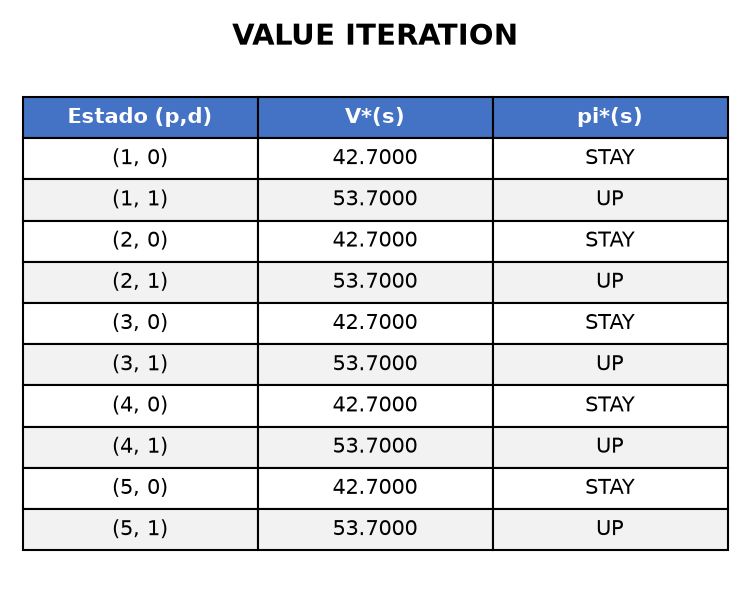


POLICY ITERATION
Iteraciones hasta convergencia : 2
Aplicaciones totales del operador de Bellman: 4670
Tiempo de ejecucion (segundos)  : 0.025174
Tabla guardada en: policy_iteration.png


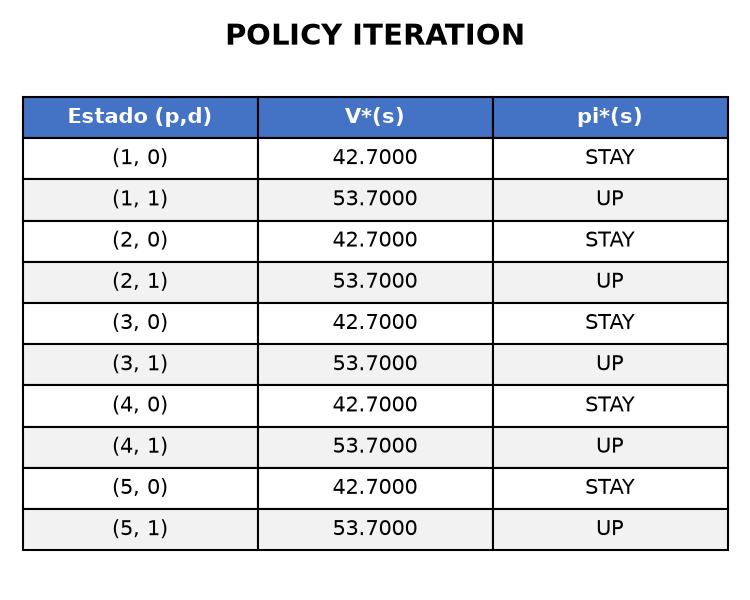


  COMPARACION
Coinciden las politicas VI y PI: True
Diferencia maxima entre V(VI) y V(PI): 7.291271820974998e-06
Tiempo VI: 0.004598 s   |   Tiempo PI: 0.025174 s


In [1]:

import time
import numpy as np
from task3.elevator import build_elevator_mdp, print_results, value_iteration, policy_iteration


P, R, states, actions, state_index = build_elevator_mdp(
    n_floors=5, p_demand=0.3
)

print(f"Numero de estados: {len(states)}")
print(f"Acciones: {actions}")

# Value Iteration
t0 = time.perf_counter()
V_vi, policy_vi, iters_vi = value_iteration(P, R, gamma=0.95, theta=1e-6)
t1 = time.perf_counter()
tiempo_vi = t1 - t0

print_results(
    "VALUE ITERATION", states, state_index, actions, V_vi, policy_vi,
    n_iters=iters_vi, elapsed=tiempo_vi
)

# Policy Iteration
t0 = time.perf_counter()
V_pi, policy_pi, iters_pi_ext, bellman_apps_pi = policy_iteration(
    P, R, gamma=0.95, theta=1e-6
)
t1 = time.perf_counter()
tiempo_pi = t1 - t0

print_results(
    "POLICY ITERATION", states, state_index, actions, V_pi, policy_pi,
    n_iters=iters_pi_ext, elapsed=tiempo_pi,
    extra_info={"Aplicaciones totales del operador de Bellman": bellman_apps_pi}
)

# Comparacion
print(f"\n{'='*55}")
print("  COMPARACION")
print(f"{'='*55}")
print("Coinciden las politicas VI y PI:",
        np.array_equal(policy_vi, policy_pi))
print("Diferencia maxima entre V(VI) y V(PI):",
        np.max(np.abs(V_vi - V_pi)))
print(f"Tiempo VI: {tiempo_vi:.6f} s   |   Tiempo PI: {tiempo_pi:.6f} s")


## Task 4

Con base en los resultados de la implementación, produzcan un dictamen técnico que incluya:

### Inciso 1

Verificación de consistencia: comprueben que las políticas óptimas producidas por Policy Iteration y Value Iteration son idénticas. Si difieren en algún estado, expliquen por qué puede ocurrir eso y cómo resolverlo. Si son idénticas, interpreten en lenguaje operacional qué le está diciendo la política óptima al sistema de control del ascensor.

### Inciso 2

Análisis de convergencia: comparen el número de iteraciones y el tiempo de ejecución de ambos algoritmos. ¿El resultado coincide con la predicción teórica que hicieron en la Tarea 2? Si no coincide, identifiquen la fuente de la discrepancia.

### Inciso 3

Análisis de sensibilidad a $\gamma$: repitan ambos algoritmos con $\gamma \in {0.5,0.75,0.99}$. Grafiquen el valor $V^*(s_0)$ del estado inicial en función de $\gamma$ para ambos algoritmos. ¿Cómo cambia la política óptima? ¿En qué valor de $\gamma$ cambia cualitativamente el comportamiento del ascensor?

### Inciso 4

Conexión con el diseño propio: comparen la política óptima obtenida para el MDP simplificado con el comportamiento que esperarían del MDP que diseñaron en la Tarea 1. ¿Qué aspectos del dominio real no captura el MDP simplificado? ¿Cómo afectaría eso a la política óptima en el dominio real?

### Inciso 5

Dictamen final: redacten un párrafo dirigido a la gerencia del hospital argumentando si Programación Dinámica es una solución viable para el sistema de ascensores real, cuáles son sus limitaciones principales, y qué metodología recomendarían como paso siguiente.